# Final Project: How does the wind effect athletes performances?
### Name: Alexia Barnes, Max Ford Wilson, Jack Howard

# Introduction

The World Athletics Database provided stats for various events recorded between 1935 and 2023. The database records professional events regarding track & field competitions, noting the Competitors names, birthdates, sex, and nationalities, their rank in the event and their results score the World Athletics Database determined themselves, the marks of the performance in either distance or time, the positions held during the performance, as well as the date, venue, wind, and event type of each performance.

Since we are focused on how windspeed impacts performance, we will filter our data to only cases where windspeed was recorded during an event. Out of the 463,847 cases our CSV file began with, we have 125,286 to work with. 

For our research, we are focused on Rank, Mark, Results Score, Event, and Wind.
* **Rank**: Rank is the performance for a given Event, split by Sex.
* **Mark [meters or seconds]**: Mark is the result entry for a given Event, given either in meters or seconds.
* **Results Score**: Results Score is the World Athletics' score assigned to each performance.
* **Event**: Event is whatever event the performance being recorded was in.
* **Wind**: Wind is the windspeed during the time of the performance.

### Exploring the Data
We begin exploring the data by looking at the dataframe. Then, we further explore variables individually.

In [1]:
# Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading in data, splitting columns
data = pd.read_csv(
    "https://raw.githubusercontent.com/thomascamminady/world-athletics-database/main/data/data.csv",
    delimiter=";",
    parse_dates=True
)
df = pd.DataFrame(data)

#Displaying the data frame
df.head()

,Rank,Mark,Competitor,DOB,Nat,Pos,Venue,Date,Results Score,Mark [meters or seconds],Event,Wind,Sex
0,1,3:43.13,Hicham EL GUERROUJ,1974-09-14,MAR,1,"Stadio Olimpico, Roma (ITA)",1999-07-07,1292,223.1,One Mile,NaN,male
1,2,3:43.40,Noah NGENY,1978-11-02,KEN,2,"Stadio Olimpico, Roma (ITA)",1999-07-07,1288,223.4,One Mile,NaN,male
2,3,3:44.39,Noureddine MORCELI,1970-02-28,ALG,1,Rieti (ITA),1993-09-05,1275,224.3,One Mile,NaN,male
3,4,3:44.60,Hicham EL GUERROUJ,1974-09-14,MAR,1,Nice (FRA),1998-07-16,1272,224.6,One Mile,NaN,male
4,5,3:44.90,Hicham EL GUERROUJ,1974-09-14,MAR,1,Oslo (NOR),1997-07-04,1268,224.9,One Mile,NaN,male


In [2]:
# df.shape
# df.columns
# df.info()

df[df['Wind'] == -9.2]

,Rank,Mark,Competitor,DOB,Nat,Pos,Venue,Date,Results Score,Mark [meters or seconds],Event,Wind,Sex
307251,25950,11.5,Marizol LANDÁZURI,1991-06-13,ECU,1,Granollers (ESP),2018-07-14,1148,11.0,100 Metres,-9.2,female


In [3]:
# We look to see when the first and last events included were recorded
print(f"First event: {df['Date'].min()}, Most recent event: {df['Date'].max()}")

First event: 1935-05-25, Most recent event: 2023-07-01


In [4]:
# We look at all counts of Events recorded
df.groupby('Event').size()

Event
10 Kilometres                1769
10 Kilometres Race Walk      2286
10 Miles Road                 306
100 Metres                  51858
100 Metres Hurdles           7585
1000 Metres                  1029
10000 Metres                 7978
10000 Metres Race Walk        687
110 Metres Hurdles          13970
15 Kilometres                 387
1500 Metres                 18563
20 Kilometres                 378
20 Kilometres Race Walk     13048
200 Metres                  37072
2000 Metres                   302
2000 Metres Steeplechase      936
20000 Metres Race Walk        203
30 Kilometres Race Walk       112
300 Metres                    994
3000 Metres                  5002
3000 Metres Race Walk         339
3000 Metres Steeplechase    24790
35 Kilometres Race Walk       924
400 Metres                  19056
400 Metres Hurdles          22480
5 Kilometres                 1783
5 Kilometres Race Walk        740
50 Kilometres Race Walk      1818
5000 Metres                 12920
5000 Met

In [5]:
# We look at count of athletes across sexes
df.groupby('Sex').size()

Sex
female    226677
male      234845
dtype: int64

## Cleaning the Data

In [6]:
# Removing rows without Wind data
filtered_df = df[df['Wind'].notna()].copy()

# Determining Competitor's Age at time of their event
filtered_df['Date'] = pd.to_datetime(filtered_df.Date)
filtered_df['DOB'] = pd.to_datetime(filtered_df.DOB)
filtered_df['Days'] = (filtered_df['Date'] - filtered_df['DOB'])
filtered_df['Age'] = (pd.to_timedelta(filtered_df['Days'], unit='D') / np.timedelta64(365, 'D'))

# Dropping unutilized columns and renaming columns
filtered_df = filtered_df.drop(columns=['Nat', 'Venue', 'Mark [meters or seconds]', 'Days', 'Pos'])
filtered_df = filtered_df.rename(columns={'Results Score' : 'Score'})


# filtered_df.head()
# filtered_df.info()
# filtered_df.groupby('Event').size()
# df.columns
filtered_df.columns

Index(['Rank', 'Mark', 'Competitor', 'DOB', 'Date', 'Score', 'Event', 'Wind',
       'Sex', 'Age'],
      dtype='str')

<Axes: xlabel='Wind', ylabel='Density'>

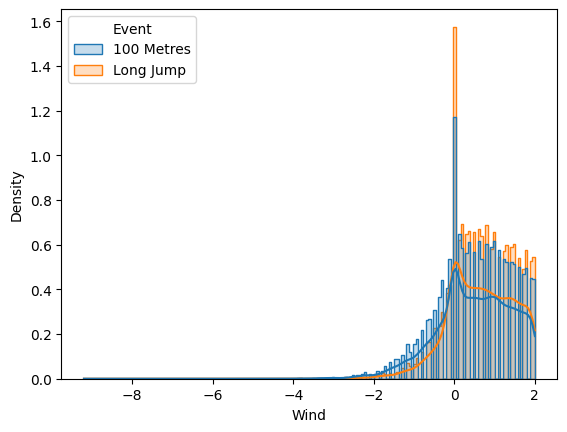

In [7]:
# Filter our dataset further to have the 2 events we're focusing on
hist_df = filtered_df[filtered_df['Event'].isin(['100 Metres', 'Long Jump'])]

# Create a histogram/density plot to compare the wind distribution of the 2 events
sns.histplot(
    data=hist_df,
    x="Wind",
    hue="Event",
    kde=True,
    stat="density",
    element="step", # outline instead of filled bars
    common_norm=False # scale event data independently since sample sizes differ greatly
)

# Very similar distributions with the most amount of records being recorded with a wind speed of abt 0.

In [8]:
# Narrowing down events and creating a dataframe for running (100m)
running_df = filtered_df[filtered_df['Event'] == '100 Metres'].copy()

# running_df.info()
# running_df.describe()

# Converting 'Mark' times to numeric instead of object dtype
running_df['Mark'] = pd.to_numeric(running_df['Mark'], errors='coerce')
running_df['Mark'].dtype
running_df[['Mark', 'Event']].sample(50)

# running_df.head()

,Mark,Event
305801,11.49,100 Metres
303574,11.47,100 Metres
292864,11.33,100 Metres
86534,10.18,100 Metres
283224,11.09,100 Metres
290379,11.29,100 Metres
295203,11.37,100 Metres
302735,11.46,100 Metres
82816,10.13,100 Metres
298075,11.40,100 Metres


<Axes: xlabel='Wind', ylabel='Score'>

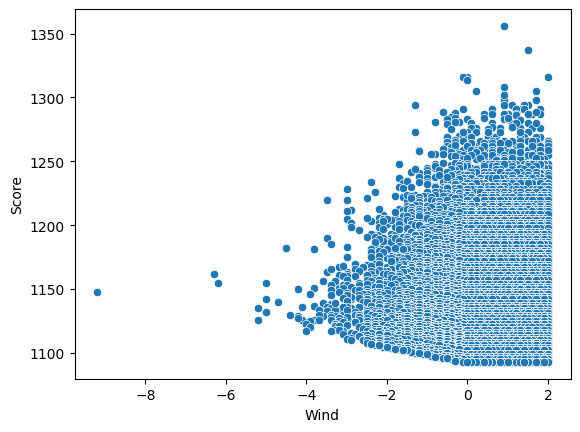

In [9]:
sns.scatterplot(x='Wind', y='Score', data=running_df)

In [10]:
wind_counts = running_df.groupby("Wind").size().reset_index(name="Count")
wind_counts.sort_values("Wind")
wind_counts

,Wind,Count
0,-9.2,1
1,-6.3,1
2,-6.2,1
3,-5.2,2
4,-5.0,3
...,...,...
66,1.6,1560
67,1.7,1458
68,1.8,1548
69,1.9,1411


<Axes: xlabel='Mark', ylabel='Density'>

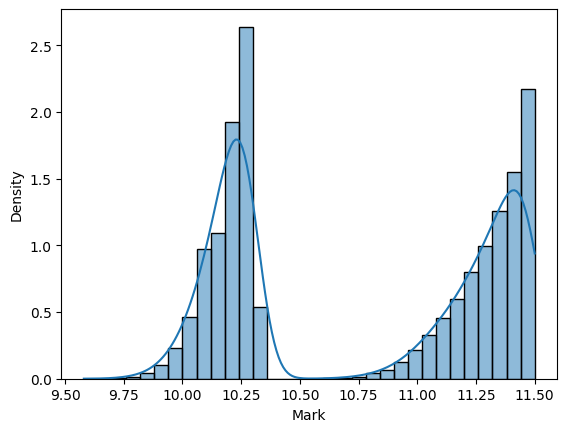

In [11]:
sns.histplot(
    data=running_df,
    x="Mark",
    kde=True,
    stat="density"
)

<Axes: xlabel='Mark', ylabel='Density'>

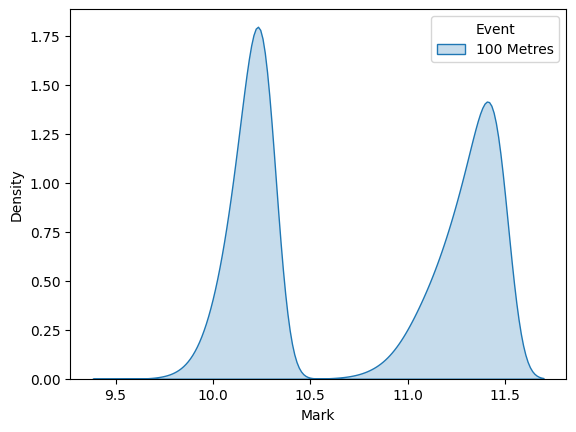

In [12]:
sns.kdeplot(data=running_df, x="Mark", hue="Event", fill=True)

<Axes: xlabel='Wind', ylabel='Mark'>

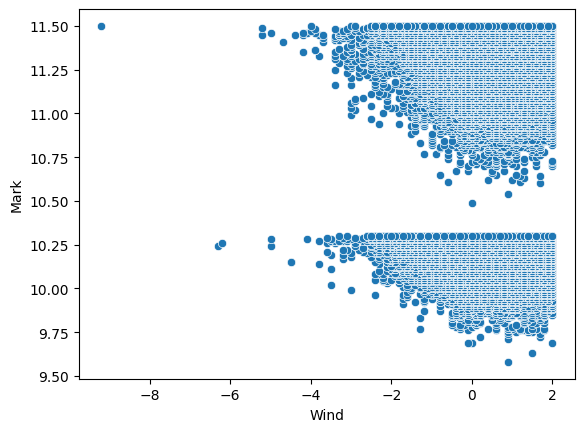

In [13]:
sns.scatterplot(x='Wind', y='Mark', data=running_df)

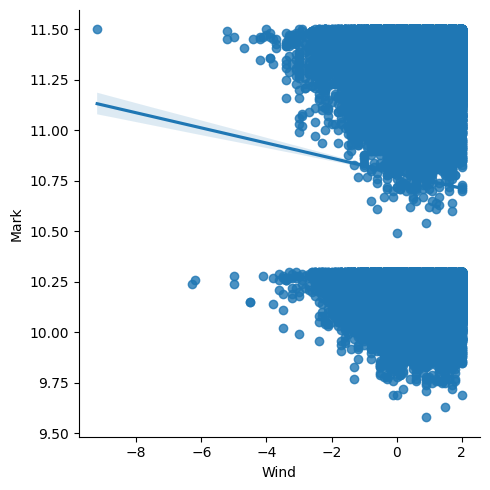

In [14]:
sns.lmplot(x='Wind', y='Mark', data=running_df)

In [15]:
# Narrowing down events and creating a dataframe for jumping (long jump)
jumping_df = filtered_df[filtered_df['Event'] == 'Long Jump'].copy()

# Converting 'Mark' times to numeric instead of object dtype
jumping_df['Mark'] = pd.to_numeric(jumping_df['Mark'], errors='coerce')
jumping_df['Mark'].dtype

# throwing_df.head()
# throwing_df.info()
jumping_df.describe()

,Rank,Mark,DOB,Date,Score,Wind,Age
count,7999.000000,7999.000000,7938,7999,7999.000000,7999.000000,7938.000000
mean,2578.013502,7.811979,1978-11-24 08:53:09.115646,2004-05-26 08:45:29.141142,1177.508814,0.659345,25.573692
min,1.000000,6.750000,1913-09-12 00:00:00,1935-05-25 00:00:00,1138.000000,-3.800000,16.013699
25%,1031.000000,7.130000,1970-01-25 00:00:00,1996-06-18 12:00:00,1153.000000,0.000000,22.910274
50%,2076.000000,8.060000,1979-06-03 12:00:00,2005-04-02 00:00:00,1170.000000,0.700000,25.349315
75%,4029.000000,8.170000,1988-09-16 00:00:00,2013-08-16 00:00:00,1194.000000,1.300000,27.854795
max,6134.000000,8.950000,2006-04-26 00:00:00,2023-07-01 00:00:00,1346.000000,2.000000,38.317808
std,1850.187102,0.569636,NaN,NaN,32.078387,0.812410,3.567369


In [16]:
wind_counts = jumping_df.groupby("Wind").size().reset_index(name="Count")
wind_counts.sort_values("Wind")
wind_counts

,Wind,Count
0,-3.8,1
1,-3.0,1
2,-2.9,1
3,-2.8,1
4,-2.7,3
5,-2.6,1
6,-2.5,4
7,-2.4,4
8,-2.3,4
9,-2.2,4


<Axes: xlabel='Mark', ylabel='Density'>

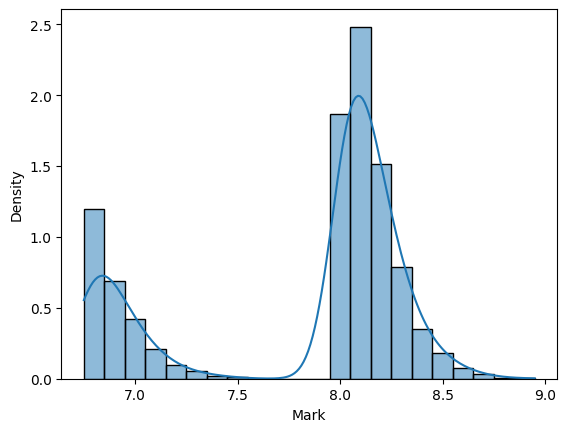

In [17]:
sns.histplot(
    data=jumping_df,
    x="Mark",
    kde=True,
    stat="density"
)

<Axes: xlabel='Wind', ylabel='Mark'>

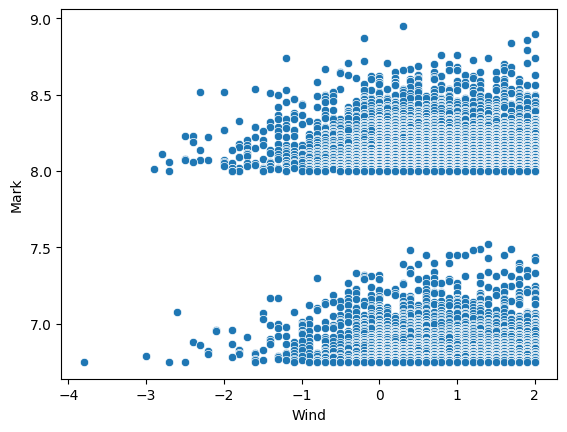

In [18]:
sns.scatterplot(x='Wind', y='Mark', data=jumping_df)

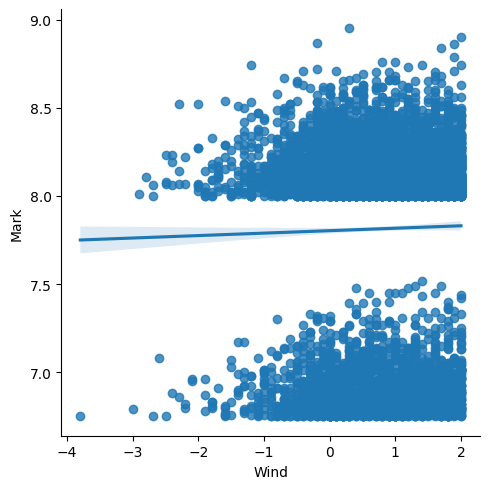

In [19]:
sns.lmplot(x='Wind', y='Mark', data=jumping_df)

## Machine Learning

Now we will apply ML methods to better understand the relationship between wind speed and perfomance. We use **K-Means Clustering** to find   tiers within the  data, and then fit **separate linear regression models** for each distinct group. Doing this we can capture the differnt relationships that may exist across many different skill levels to avoid generalizing the data. 

### K-Means Clustering (100 Metres)

Based on the scatter plot of Wind vs. Mark, there seem to be two distinct groups. Using K-means clustering we can separate these groups and model them independently. 

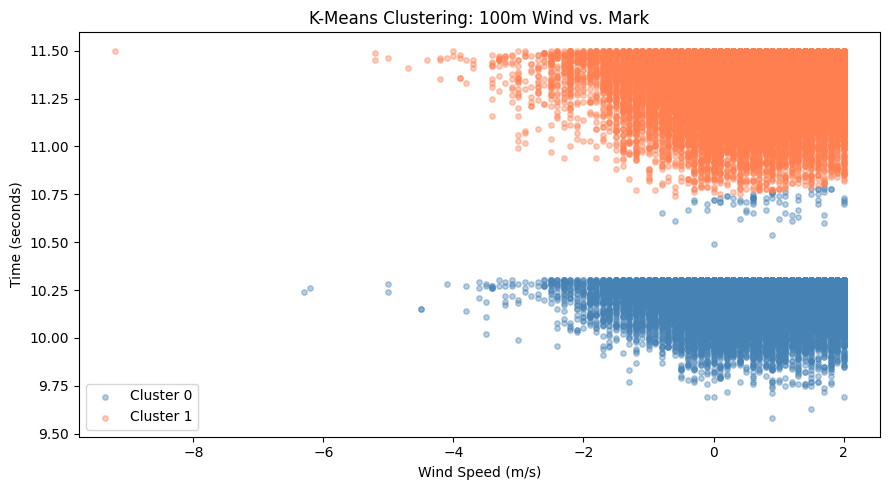

Cluster
1    26225
0    24519
Name: Count, dtype: int64


In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

kmeans_df = running_df[["Wind", "Mark"]].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(kmeans_df)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_df["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(9, 5))
for cluster_id, color, label in zip([0, 1], ["steelblue", "coral"], ["Cluster 0", "Cluster 1"]):
    subset = kmeans_df[kmeans_df["Cluster"] == cluster_id]
    plt.scatter(subset["Wind"], subset["Mark"], alpha=0.4, s=15, color=color, label=label)

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Time (seconds)")
plt.title("K-Means Clustering: 100m Wind vs. Mark")
plt.legend()
plt.tight_layout()
plt.show()

# Cluster sizes
print(kmeans_df["Cluster"].value_counts().rename("Count"))

The two clusters reflect meaningful performance tiers. One cluster has faster athletes while the other likely contains amateur athletes. Separating them helps us avoid fitting a single regression line through two different populations, because that would produce a misleading average.

### Linear Regression Per Cluster (100 Metres)

Now we fit a separate linear regression model for each cluster to find how wind speed predicts finishing time within each group.

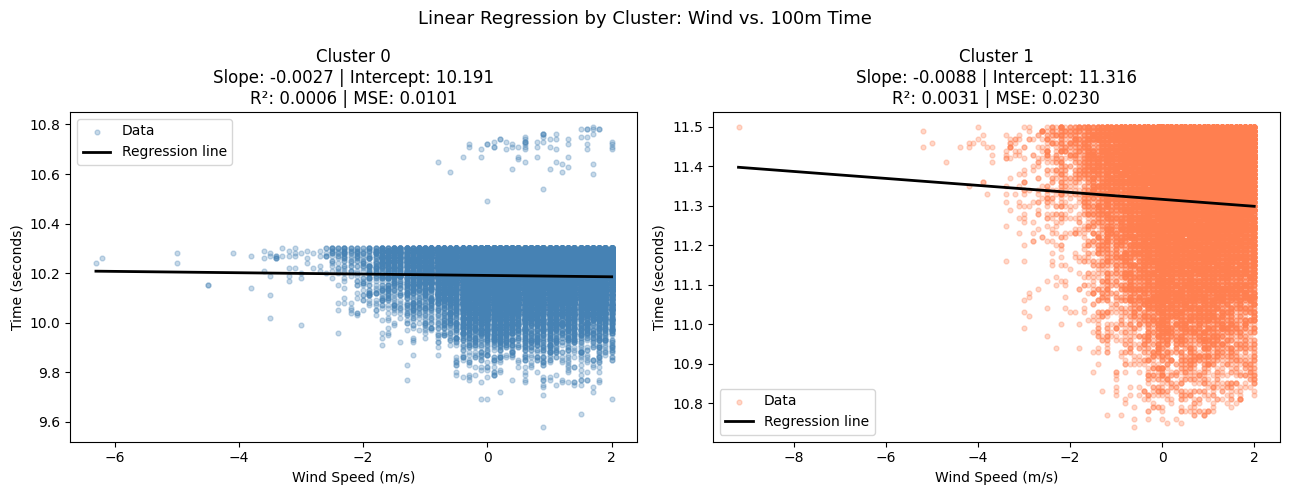

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cluster_labels = {0: "Cluster 0", 1: "Cluster 1"}
colors = {0: "steelblue", 1: "coral"}

for cluster_id in [0, 1]:
    subset = kmeans_df[kmeans_df["Cluster"] == cluster_id].copy()
    X = subset[["Wind"]]
    y = subset["Mark"]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    ax = axes[cluster_id]
    ax.scatter(subset["Wind"], subset["Mark"], alpha=0.3, s=12, color=colors[cluster_id], label="Data")

    wind_range = pd.DataFrame(np.linspace(subset["Wind"].min(), subset["Wind"].max(), 200), columns=["Wind"])
    ax.plot(wind_range, model.predict(wind_range), color="black", linewidth=2, label="Regression line")

    ax.set_title(f'{cluster_labels[cluster_id]}\nSlope: {model.coef_[0]:.4f} | Intercept: {model.intercept_:.3f}\nR²: {r2:.4f} | MSE: {mse:.4f}')
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Time (seconds)")
    ax.legend()

plt.suptitle("Linear Regression by Cluster: Wind vs. 100m Time", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
results = []
for cluster_id in [0, 1]:
    subset = kmeans_df[kmeans_df["Cluster"] == cluster_id].copy()
    X = subset[["Wind"]]
    y = subset["Mark"]
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    results.append({
        "Cluster": cluster_id,
        "Slope": round(model.coef_[0], 4),
        "Intercept": round(model.intercept_, 4),
        "R2": round(r2_score(y, y_pred), 4),
        "MSE": round(mean_squared_error(y, y_pred), 4)
    })

import pandas as pd
print(pd.DataFrame(results).to_string(index=False))

 Cluster   Slope  Intercept     R2    MSE
       0 -0.0027    10.1906 0.0006 0.0101
       1 -0.0088    11.3164 0.0031 0.0230
